# AK-IS basic example

This notebook runs AK-IS with the default iHL-RF direction searcher. The resulting design point is used as the center of the Gaussian importance-sampling proposal.


In [4]:
import numpy as np
from ak_based_sampler import AK_IS


def limit_state_function(u):
    return 0.5 * (u[..., 0] - 2)**2 - 1.5 * (u[..., 1] - 5)**3 - 3

In [5]:
sampler = AK_IS(dim=2, LSF=limit_state_function)

# Keep the example lightweight enough to run interactively.
sampler.set_parameters(
    n_initial_population=20_000,
    n_initial_DoEs=10,
    u_stop=2.0,
    max_iterations_u=50,
)

pf = sampler(seed=1, verbose=True)

print(f"Estimated failure probability: {pf:.6g}")
print(dict(sampler.result))


[AK-IS] Start AK-IS: dim=2, center=[0.78388327 3.85349345], population=20000
[AK-IS] U iteration 1/50: min U=0.00272647
[AK-IS] U iteration 2/50: min U=0.00109743
c:\Projects\reliability_analysis\AK-based-sampling\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 17 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
[AK-IS] U iteration 3/50: min U=0.0415945
c:\Projects\reliability_analysis\AK-based-sampling\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 19 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
[AK-IS] U iteration 4/50: min U=0.665002
c:\Projects\reliability_analysis

Estimated failure probability: 2.88049e-05
{'pf': 2.8804918970985406e-05, 'n_called': 14, 'n_population': 20000, 'min_u_value': 2.7296619154685433, 'cov': 0.01676102561059696, 'sample_center': array([0.78388327, 3.85349345])}


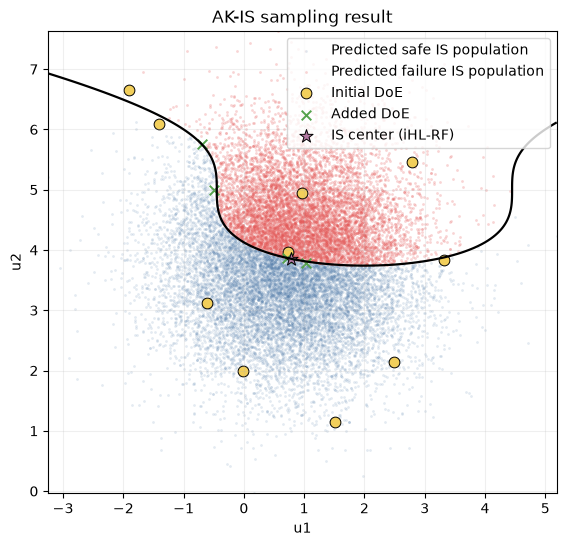

Importance-weight range: [2.29e-10, 2.24e+03]


In [6]:
import matplotlib.pyplot as plt

initial_u, initial_g = sampler.train_data["initial_DoE"]
added_u, added_g = sampler.train_data["DoE"]
population_u, population_g, population_sigma, weights = sampler.train_data["population"]
center = sampler.result["sample_center"]

failure_mask = population_g <= 0.0

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(
    population_u[~failure_mask, 0],
    population_u[~failure_mask, 1],
    s=4, c="#4c78a8", alpha=0.15, linewidths=0,
    label="Predicted safe IS population",
)
ax.scatter(
    population_u[failure_mask, 0],
    population_u[failure_mask, 1],
    s=4, c="#e45756", alpha=0.25, linewidths=0,
    label="Predicted failure IS population",
)
ax.scatter(
    initial_u[:, 0], initial_u[:, 1],
    s=60, c="#f2cf5b", edgecolors="black", linewidths=0.7,
    label="Initial DoE",
)
if len(added_u) > 0:
    ax.scatter(
        added_u[:, 0], added_u[:, 1],
        s=48, marker="x", c="#54a24b", linewidths=1.4,
        label="Added DoE",
    )
ax.scatter(
    center[0], center[1], s=100, marker="*", c="#b279a2",
    edgecolors="black", linewidths=0.7, label="IS center (iHL-RF)",
)

grid_x = np.linspace(population_u[:, 0].min(), population_u[:, 0].max(), 250)
grid_y = np.linspace(population_u[:, 1].min(), population_u[:, 1].max(), 250)
xx, yy = np.meshgrid(grid_x, grid_y)
zz = limit_state_function(np.stack([xx, yy], axis=-1))
ax.contour(xx, yy, zz, levels=[0.0], colors="black", linewidths=1.6)

ax.set_title("AK-IS sampling result")
ax.set_xlabel("u1")
ax.set_ylabel("u2")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper right", frameon=True)
ax.grid(alpha=0.2)
plt.show()

print(f"Importance-weight range: [{weights.min():.3g}, {weights.max():.3g}]")
